# Knee OA: Concept-Bottleneck Decomposition of Cross-Hospital Grading Disagreement

**The claim under test.** A KL grade is not one atomic judgment. It decomposes as

```
Image  --P(Findings|Image)-->  Findings (osteophyte, JSN, sclerosis)  --P(Grade|Findings)-->  KL grade
```

**H1:** hospital differences act mainly on `P(Grade|Findings)` (the grading *policy*), while `P(Findings|Image)`
(what the image shows) is stable and transports for free.

This is a **causal transportability** question — which mechanism is invariant across environments, and which must
be re-estimated — and the architecture above is a **Concept Bottleneck Model (CBM)**: the model must express its
reasoning through human-readable clinical concepts before predicting the grade. That framing buys two things
ordinary models don't have: (1) *test-time intervention* — overwrite predicted findings with ground truth and watch
the grade correct itself, without retraining; (2) an interpretable, cheaply-adaptable policy head.

### What makes this dataset special: a perfect natural experiment

Mendeley (Chen 2018) is **organized from OAI** — the same knees. This notebook verifies that directly (Part 1) and
then exploits it (Part 2): for knees present in both, `P(Grade|Findings)` is held **exactly** constant by
construction (identical labels, identical anatomy), so **any** prediction difference is *pure* `P(Findings|Image)`
instability caused by the image pipeline. That is a control condition you cannot buy — no confound from different
patients, different graders, or different disease prevalence.

### Parts
| Part | Question |
|---|---|
| 1 | **Provenance audit** — is Mendeley an independent cohort, or a copy of OAI? What does that do to LODO? |
| 2 | **Natural experiment** — same model, same knee, same label, different pipeline: how unstable is Image→Findings? |
| 3 | **H1 test** — is the findings→grade relationship consistent across the *genuinely* independent cohorts? |
| 4 | **Adaptation** — refit only the policy head (linear vs interpretable tree) on few labels vs baselines |
| 5 | **Test-time intervention** — replace predicted findings with ground truth; does the grade recover? |

**Input:** the four `*_findings.csv` files from `mt2_multitask_trainer.ipynb`. Real data only — if they're missing,
this raises rather than substituting anything.

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('(not on Colab or already mounted):', e)

import os, glob, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import cohen_kappa_score, accuracy_score
from scipy.stats import spearmanr
from collections import Counter
warnings.filterwarnings('ignore')

# Interpretable tree policy head. FIGS (Fast Interpretable Greedy Sum-Trees) is the method from the
# 2025 CBM distillation work; a depth-limited sklearn tree is the dependency-free fallback and
# captures the same thing that matters here: FINDING INTERACTIONS a linear rule cannot express.
try:
    from imodels import FIGSClassifier
    HAS_FIGS = True
except Exception:
    try:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'imodels'], check=True)
        from imodels import FIGSClassifier
        HAS_FIGS = True
    except Exception as e:
        print('[note] FIGS unavailable, using depth-limited sklearn tree instead:', type(e).__name__)
        HAS_FIGS = False
print('FIGS available:', HAS_FIGS)

Mounted at /content/drive
FIGS available: True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ------------------------------- CONFIG -------------------------------
ALL_COHORTS  = ["OAI", "NHANES", "MRKR", "Mendeley"]
TRUE_COHORTS = ["OAI", "NHANES", "MRKR"]      # Mendeley is a duplicate of OAI (Part 1) -> control, not a cohort
FEATS        = ["osteophyte", "jsn", "sclerosis"]
FEAT_COLS    = [f + "_pred" for f in FEATS]
TRUE_COLS    = [f + "_true" for f in FEATS]
CALIB_SIZES  = [20, 50, 100, 200]
N_REPS       = 5
MIN_PER_GRADE = 3
SEED = 0
MISSING_SENTINEL = -1          # your masked sub-feature loss uses -1 for "no ground truth"
C_MAP = {"OAI":"#2a7fb8","NHANES":"#2a9d8f","MRKR":"#8a5cb0","Mendeley":"#c44e52"}

FINDINGS_SEARCH_DIRS = [
    "/content/drive/MyDrive/Master Thesis/scope3_mt/results",
    "/mnt/user-data/uploads", ".", "./results",
]
RAW_TO_DISPLAY = {"oai":"OAI", "nhanes3":"NHANES", "mrkr":"MRKR", "mendeley":"Mendeley"}

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def _find_findings_files():
    fs = []
    for d in FINDINGS_SEARCH_DIRS:
        fs += glob.glob(os.path.join(d, "*_findings.csv"))
    return sorted(set(fs))

def load_findings_per_run():
    # IMPORTANT: keep runs SEPARATE. Each file = ONE model applied to ALL cohorts.
    # Part 2's deconfounded comparison needs a single model's predictions on both
    # the OAI-path and Mendeley-path version of the same knee.
    files = _find_findings_files()
    if not files:
        raise FileNotFoundError(
            "No *_findings.csv found. Run mt2_multitask_trainer.ipynb (all 4 folds) first.\n"
            "Searched: " + str(FINDINGS_SEARCH_DIRS))
    runs = {}
    for f in files:
        run = os.path.basename(f).replace("_findings.csv", "")
        d = pd.read_csv(f)
        d["dataset"] = d["dataset"].replace(RAW_TO_DISPLAY)
        need = {"image_id","patient_id","dataset","kl_label", *FEAT_COLS}
        missing = need - set(d.columns)
        assert not missing, f"{run}: missing columns {missing}"
        runs[run] = d
        print("  %-24s %6d rows | cohorts: %s" % (run, len(d), sorted(d.dataset.unique())))
    return runs

print("findings files:")
RUNS = load_findings_per_run()
print("\nloaded %d runs" % len(RUNS))

findings files:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  mt_mendeley_seed0         61558 rows | cohorts: ['MRKR', 'Mendeley', 'NHANES', 'OAI']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  mt_mrkr_seed0             61558 rows | cohorts: ['MRKR', 'Mendeley', 'NHANES', 'OAI']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  mt_nhanes3_seed0          61558 rows | cohorts: ['MRKR', 'Mendeley', 'NHANES', 'OAI']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  mt_oai_seed0              61558 rows | cohorts: ['MRKR', 'Mendeley', 'NHANES', 'OAI']

loaded 4 runs


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Part 1 — Provenance audit: is Mendeley an independent cohort?

Parse `(subject_id, side)` out of each cohort's filenames and look for collisions. Two independent hospitals
cannot share subject IDs *and* labels. NHANES/MRKR act as **negative controls** — if the matching logic is sound,
they must show ~zero overlap with OAI.

In [ ]:
PARSERS = {
    "OAI":      lambda x: (lambda m: f"{m.group(1)}{m.group(2)}" if m else None)(re.search(r'OAI_(\d{7})_([LR])', x)),
    "Mendeley": lambda x: (lambda m: f"{m.group(1)}{m.group(2)}" if m else None)(re.search(r'(\d{7})([LR])\.png$', x)),
    "NHANES":   lambda x: (lambda m: f"{m.group(1)}{m.group(2)}" if m else None)(re.search(r'SEQN(\d+)_([LR])', x)),
    "MRKR":     lambda x: (lambda m: f"{m.group(1)}{m.group(2)}" if m else None)(re.search(r'MRKR_(\d+)_([LR])', x)),
}

def add_knee_key(d):
    d = d.copy()
    d["knee_key"] = [PARSERS.get(ds, lambda x: None)(iid) for ds, iid in zip(d.dataset, d.image_id)]
    return d

audit_df = add_knee_key(next(iter(RUNS.values())))     # provenance is a property of the data, any run works
print("knee_key parse rate per cohort:")
print(audit_df.groupby("dataset").knee_key.apply(lambda s: "%d/%d" % (s.notna().sum(), len(s))).to_string())

keys = {c: set(audit_df[audit_df.dataset == c].knee_key.dropna()) for c in ALL_COHORTS if (audit_df.dataset == c).any()}
print("\n=== overlap with OAI (subject+side) ===")
for c in [x for x in ALL_COHORTS if x != "OAI" and x in keys]:
    ov = keys["OAI"] & keys[c]
    tag = "  <-- NEGATIVE CONTROL, expect ~0" if c in ("NHANES", "MRKR") else "  <-- !!"
    print("  OAI \u2229 %-9s %6d shared knees (%.1f%% of %s)%s" %
          (c, len(ov), 100*len(ov)/max(len(keys[c]),1), c, tag))

# On shared knees, are the LABELS identical? Independent graders cannot agree perfectly.
if "Mendeley" in keys:
    o = audit_df[(audit_df.dataset=="OAI") & audit_df.knee_key.notna()][["knee_key","kl_label"]].rename(columns={"kl_label":"kl_oai"})
    m = audit_df[(audit_df.dataset=="Mendeley") & audit_df.knee_key.notna()][["knee_key","kl_label"]].rename(columns={"kl_label":"kl_men"})
    pair = o.merge(m, on="knee_key", how="inner").drop_duplicates("knee_key")
    if len(pair):
        agree = (pair.kl_oai == pair.kl_men).mean()
        kap = cohen_kappa_score(pair.kl_oai, pair.kl_men, weights="quadratic")
        print("\n=== SAME KNEE, both cohorts' labels (n=%d) ===" % len(pair))
        print("  exact label agreement: %.4f" % agree)
        print("  QWK between them:      %.4f" % kap)
        print("  mean signed diff (OAI - Mendeley): %+.4f" % (pair.kl_oai - pair.kl_men).mean())
        print("\n  cross-tab (rows=OAI, cols=Mendeley):")
        print(pd.crosstab(pair.kl_oai, pair.kl_men).to_string())
        if agree > 0.99:
            print("\n  >>> VERDICT: labels are IDENTICAL -> Mendeley is a COPY of OAI, not an independent cohort.")
            print("  >>> Consequence: folds holding out Mendeley train on these exact knees via OAI (and vice")
            print("  >>>              versa) -> those folds are CONTAMINATED and are not external validation.")
            print("  >>> Consequence: P(Grade|Findings) is identical by construction -> Mendeley is a perfect")
            print("  >>>              CONTROL for isolating pure P(Findings|Image) shift (Part 2).")
SHARED_KNEES = set(pair.knee_key) if 'pair' in dir() and len(pair) else set()
print("\nshared knees available for Part 2:", len(SHARED_KNEES))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

knee_key parse rate per cohort:
dataset
MRKR        39967/39967
Mendeley      8259/8259
NHANES        4785/4785
OAI           8547/8547

=== overlap with OAI (subject+side) ===
  OAI ∩ NHANES         0 shared knees (0.0% of NHANES)  <-- NEGATIVE CONTROL, expect ~0
  OAI ∩ MRKR           0 shared knees (0.0% of MRKR)  <-- NEGATIVE CONTROL, expect ~0
  OAI ∩ Mendeley    7917 shared knees (95.9% of Mendeley)  <-- !!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



=== SAME KNEE, both cohorts' labels (n=7917) ===
  exact label agreement: 1.0000
  QWK between them:      1.0000
  mean signed diff (OAI - Mendeley): +0.0000

  cross-tab (rows=OAI, cols=Mendeley):
kl_men     0     1     2     3    4
kl_oai                             
0       3147     0     0     0    0
1          0  1434     0     0    0
2          0     0  2061     0    0
3          0     0     0  1036    0
4          0     0     0     0  239

  >>> VERDICT: labels are IDENTICAL -> Mendeley is a COPY of OAI, not an independent cohort.
  >>> Consequence: folds holding out Mendeley train on these exact knees via OAI (and vice
  >>>              versa) -> those folds are CONTAMINATED and are not external validation.
  >>> Consequence: P(Grade|Findings) is identical by construction -> Mendeley is a perfect
  >>>              CONTROL for isolating pure P(Findings|Image) shift (Part 2).

shared knees available for Part 2: 7917


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Part 2 — The natural experiment (the ceiling result)

For the shared knees, take **one run** (= one model) and compare its predictions on the *OAI-path* file versus the
*Mendeley-path* file of the **same knee**. Same model, same anatomy, same ground-truth grade — the **only**
difference is the image preprocessing pipeline.

Therefore any disagreement here is **pure `P(Findings|Image)` instability**, with `P(Grade|Findings)` held exactly
constant. This is the cleanest possible test of H1's premise that "what the image shows" transports for free.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Same model, same knee, same label — ONLY the image pipeline differs.



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,run,n_knees,label_identical,kl_agreement,kl_qwk_selfconsistency,osteophyte_agree,osteophyte_bias,osteophyte_mae,jsn_agree,jsn_bias,jsn_mae,sclerosis_agree,sclerosis_bias,sclerosis_mae
0,mt_mendeley_seed0,7917,1.0,0.455,0.377,0.618,0.100,0.487,0.527,-0.221,0.622,0.803,0.208,0.274
1,mt_mrkr_seed0,7917,1.0,0.810,0.799,0.844,0.121,0.195,0.871,0.080,0.163,0.906,0.055,0.111
2,mt_nhanes3_seed0,7917,1.0,0.836,0.843,0.826,-0.008,0.232,0.804,-0.091,0.200,0.896,-0.017,0.113
3,mt_oai_seed0,7917,1.0,0.705,0.640,0.976,0.027,0.072,0.411,1.713,1.768,0.325,2.008,2.024


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


label_identical should be 1.000 (that is the control working: the grade truth is held fixed).
Everything below 1.000 elsewhere is instability the pipeline ALONE introduced.



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

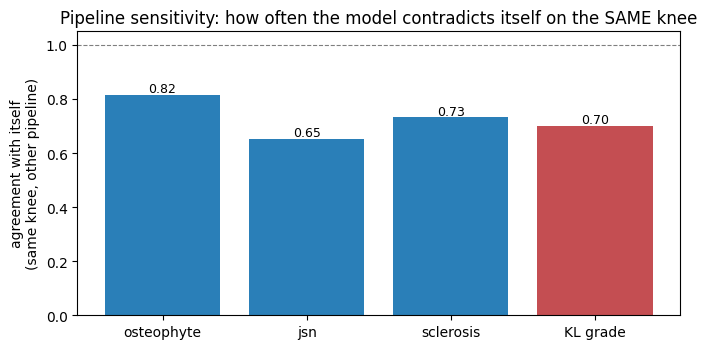

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

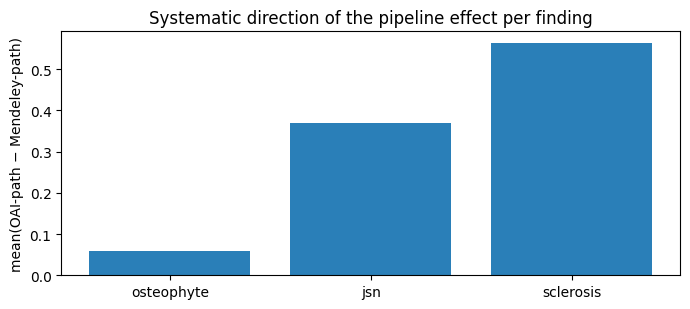

Non-zero bias = the pipeline doesn't just add noise, it SHIFTS a finding in a consistent direction.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def pipeline_instability(run_df, run_name):
    d = add_knee_key(run_df)
    d = d[d.knee_key.isin(SHARED_KNEES)]
    o = d[d.dataset == "OAI"].set_index("knee_key")
    m = d[d.dataset == "Mendeley"].set_index("knee_key")
    common = o.index.intersection(m.index)
    if len(common) == 0: return None
    o, m = o.loc[common], m.loc[common]
    rec = {"run": run_name, "n_knees": len(common),
           "label_identical": float((o.kl_label.values == m.kl_label.values).mean())}
    # grade-level instability
    rec["kl_agreement"] = float((o.kl_pred.values == m.kl_pred.values).mean())
    rec["kl_qwk_selfconsistency"] = float(cohen_kappa_score(o.kl_pred, m.kl_pred, weights="quadratic",
                                                            labels=[0,1,2,3,4]))
    # findings-level instability -- the direct P(Findings|Image) measurement
    for f in FEATS:
        a, b = o[f + "_pred"].values, m[f + "_pred"].values
        rec[f + "_agree"] = float((a == b).mean())
        rec[f + "_bias"] = float((a - b).mean())          # systematic direction of the pipeline effect
        rec[f + "_mae"] = float(np.abs(a - b).mean())
    return rec

rows = [r for rn, rd in RUNS.items() if (r := pipeline_instability(rd, rn)) is not None]
inst = pd.DataFrame(rows)
if len(inst) == 0:
    print("No shared knees resolved — Part 2 skipped.")
else:
    print("Same model, same knee, same label — ONLY the image pipeline differs.\n")
    display(inst.round(3))
    print("\nlabel_identical should be 1.000 (that is the control working: the grade truth is held fixed).")
    print("Everything below 1.000 elsewhere is instability the pipeline ALONE introduced.\n")

    agg = inst[[f + "_agree" for f in FEATS] + ["kl_agreement"]].mean()
    fig, ax = plt.subplots(figsize=(7, 3.6))
    names = FEATS + ["KL grade"]
    vals = [agg[f + "_agree"] for f in FEATS] + [agg["kl_agreement"]]
    ax.bar(names, vals, color=["#2a7fb8"]*3 + ["#c44e52"])
    for i, v in enumerate(vals): ax.text(i, v + .01, "%.2f" % v, ha="center", fontsize=9)
    ax.axhline(1.0, ls="--", lw=.8, color="k", alpha=.5)
    ax.set_ylim(0, 1.05); ax.set_ylabel("agreement with itself\n(same knee, other pipeline)")
    ax.set_title("Pipeline sensitivity: how often the model contradicts itself on the SAME knee")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(7, 3.2))
    biases = [inst[f + "_bias"].mean() for f in FEATS]
    ax.bar(FEATS, biases, color="#2a7fb8"); ax.axhline(0, color="k", lw=.6)
    ax.set_ylabel("mean(OAI-path − Mendeley-path)")
    ax.set_title("Systematic direction of the pipeline effect per finding")
    plt.tight_layout(); plt.show()
    print("Non-zero bias = the pipeline doesn't just add noise, it SHIFTS a finding in a consistent direction.")

## Part 3 — H1 test on the genuinely independent cohorts

Mendeley is excluded here (Part 1 showed it's a copy of OAI — including it would double-count OAI and contaminate
the comparison). Within each real cohort, does each finding relate to that cohort's own KL grade the same way?
Similar magnitude and sign across cohorts supports H1; a finding that collapses or flips does not.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

using run: mt_mendeley_seed0 | (each run = one model over all cohorts; cohort rows are the same images)
cohorts analysed: ['OAI', 'NHANES', 'MRKR']   (Mendeley excluded: duplicate of OAI)



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,OAI,NHANES,MRKR
finding,,,
osteophyte,0.820,0.817,0.635
jsn,0.764,0.747,0.640
sclerosis,0.694,0.626,0.602


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

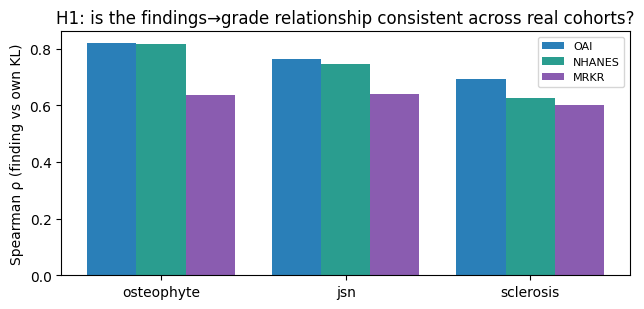

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Extractor accuracy vs OAI ground truth (this is the CEILING everything downstream inherits):
  osteophyte  exact=0.660  QWK=0.716  (n=5253)
  jsn         exact=0.795  QWK=0.852  (n=8547)
  sclerosis   exact=0.762  QWK=0.814  (n=5252)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
main_run = sorted(RUNS.keys())[0]
df = RUNS[main_run].copy()
print("using run:", main_run, "| (each run = one model over all cohorts; cohort rows are the same images)")
PRESENT = [c for c in TRUE_COHORTS if (df.dataset == c).any()]
print("cohorts analysed:", PRESENT, "  (Mendeley excluded: duplicate of OAI)\n")

corr_rows = []
for f in FEATS:
    row = {"finding": f}
    for c in PRESENT:
        s = df[df.dataset == c]
        row[c] = round(spearmanr(s[f + "_pred"], s["kl_label"])[0], 3) if s[f+"_pred"].nunique() > 1 else np.nan
    corr_rows.append(row)
corr_df = pd.DataFrame(corr_rows).set_index("finding")
display(corr_df)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
x = np.arange(len(FEATS)); w = 0.8/max(len(PRESENT),1)
for i, c in enumerate(PRESENT):
    ax.bar(x + i*w, corr_df[c].values, w, label=c, color=C_MAP.get(c))
ax.set_xticks(x + w*(len(PRESENT)-1)/2); ax.set_xticklabels(FEATS)
ax.set_ylabel("Spearman \u03c1 (finding vs own KL)"); ax.axhline(0, color="k", lw=.6)
ax.legend(fontsize=8); ax.set_title("H1: is the findings\u2192grade relationship consistent across real cohorts?")
plt.tight_layout(); plt.show()

# extractor quality ceiling where ground truth exists
oai = df[df.dataset == "OAI"]
have_true = [f for f in FEATS if (f+"_true") in oai.columns and (oai[f+"_true"] != MISSING_SENTINEL).any()]
if have_true:
    print("Extractor accuracy vs OAI ground truth (this is the CEILING everything downstream inherits):")
    for f in have_true:
        m = (oai[f+"_true"].notna()) & (oai[f+"_true"] != MISSING_SENTINEL)
        print("  %-11s exact=%.3f  QWK=%.3f  (n=%d)" % (
            f, accuracy_score(oai.loc[m, f+"_true"], oai.loc[m, f+"_pred"]),
            cohen_kappa_score(oai.loc[m, f+"_true"], oai.loc[m, f+"_pred"], weights="quadratic"), m.sum()))

## Part 4 — Adaptation: refit only the policy head

**Method 1 — no adaptation:** policy head fit on the *other* cohorts, applied as-is.
**Method 2 — linear policy head:** refit multinomial logistic regression on a small labeled slice.
**Method 3 — interpretable tree policy head (FIGS):** same slice, but the head can express *interactions*
(e.g. "severe JSN **and** large osteophyte → KL4"), which a linear rule structurally cannot. Still fully
readable and still adapts from a handful of labels.

Methods needing backprop (last-layer / full fine-tuning) can't be computed from saved predictions — paste them
into `EXTERNAL_RESULTS` for the complete comparison table.

> Calibration and evaluation slices are disjoint at the patient level, stratified so every grade is represented,
> and averaged over repeated draws. Only the head changes; ground-truth labels are never rewritten.

In [ ]:
EXTERNAL_RESULTS = {
    # ("NHANES", 100): {"m_lastlayer_qwk": 0.70, "m_fullft_qwk": 0.66},
}

def group_calib_split(sub, target_n, seed, stratify=True, min_per_grade=MIN_PER_GRADE):
    rng = np.random.default_rng(seed)
    groups = np.array(sub["patient_id"].unique(), dtype=object); rng.shuffle(groups)
    sizes = sub.groupby("patient_id").size()
    pid = sub["patient_id"].to_numpy(); y = sub["kl_label"].to_numpy()
    picked, pickset, total = [], set(), 0
    def add(p):
        nonlocal total
        picked.append(p); pickset.add(p); total += int(sizes[p])
    if stratify:
        gc = Counter()
        for g in sorted(set(y.tolist())):
            for p in groups:
                if gc[g] >= min_per_grade: break
                if p in pickset: continue
                if ((pid == p) & (y == g)).any():
                    add(p)
                    for gg, cnt in Counter(y[pid == p]).items(): gc[gg] += cnt
    for p in groups:
        if total >= target_n: break
        if p not in pickset: add(p)
    return sub["patient_id"].isin(picked).to_numpy()

def qwk(a, b):
    a = np.asarray(a)
    if len(a) == 0: return np.nan
    k = cohen_kappa_score(a, b, weights="quadratic", labels=[0,1,2,3,4]); return 0.0 if np.isnan(k) else k
def acc(a, b):
    a = np.asarray(a); return np.nan if len(a) == 0 else accuracy_score(a, b)

def fit_linear(X, y):
    return None if len(np.unique(y)) < 2 else LogisticRegression(max_iter=1000).fit(X, y)

def fit_tree(X, y, max_rules=12, max_depth=3):
    if len(np.unique(y)) < 2: return None
    if HAS_FIGS:
        try: return FIGSClassifier(max_rules=max_rules).fit(X, y)
        except Exception: pass
    return DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=3, random_state=0).fit(X, y)

def pred_or(model, X, fallback):
    if model is None: return np.full(len(X), fallback)
    p = np.asarray(model.predict(X)).ravel()
    return np.clip(np.rint(p).astype(int), 0, 4)

records = []
for c in PRESENT:
    sub = df[df.dataset == c].reset_index(drop=True)
    X, y = sub[FEAT_COLS].to_numpy(), sub["kl_label"].to_numpy()
    others = df[(df.dataset != c) & (df.dataset.isin(PRESENT))]
    pooled = fit_linear(others[FEAT_COLS].to_numpy(), others["kl_label"].to_numpy())
    fb = int(pd.Series(y).mode().iloc[0])
    for n in CALIB_SIZES:
        if n >= len(sub): continue
        r = {k: [] for k in ["m1_a","m1_q","m2_a","m2_q","m3_a","m3_q"]}
        for rep in range(N_REPS):
            cm = group_calib_split(sub, n, seed=1000*rep + n); em = ~cm
            if cm.sum() == 0 or em.sum() == 0: continue
            r["m1_a"].append(acc(y[em], pred_or(pooled, X[em], fb)));  r["m1_q"].append(qwk(y[em], pred_or(pooled, X[em], fb)))
            lin = fit_linear(X[cm], y[cm])
            r["m2_a"].append(acc(y[em], pred_or(lin, X[em], fb)));     r["m2_q"].append(qwk(y[em], pred_or(lin, X[em], fb)))
            tre = fit_tree(X[cm], y[cm])
            r["m3_a"].append(acc(y[em], pred_or(tre, X[em], fb)));     r["m3_q"].append(qwk(y[em], pred_or(tre, X[em], fb)))
        if not r["m1_a"]: continue
        rec = dict(cohort=c, calib_n=n,
                   noadapt_qwk=np.mean(r["m1_q"]),
                   linear_qwk=np.mean(r["m2_q"]), linear_sd=np.std(r["m2_q"]),
                   tree_qwk=np.mean(r["m3_q"]),  tree_sd=np.std(r["m3_q"]),
                   noadapt_acc=np.mean(r["m1_a"]), linear_acc=np.mean(r["m2_a"]), tree_acc=np.mean(r["m3_a"]))
        rec.update(EXTERNAL_RESULTS.get((c, n), {}))
        records.append(rec)

res = pd.DataFrame(records)
res["tree_vs_linear"] = res.tree_qwk - res.linear_qwk
res["tree_vs_noadapt"] = res.tree_qwk - res.noadapt_qwk
print("mean over %d stratified draws | head = %s\n" % (N_REPS, "FIGS" if HAS_FIGS else "sklearn tree"))
res.round(3)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

mean over 5 stratified draws | head = FIGS



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,cohort,calib_n,noadapt_qwk,linear_qwk,linear_sd,tree_qwk,tree_sd,noadapt_acc,linear_acc,tree_acc,tree_vs_linear,tree_vs_noadapt
0,OAI,20,0.823,0.772,0.052,0.794,0.046,0.670,0.589,0.664,0.022,-0.029
1,OAI,50,0.824,0.839,0.010,0.834,0.011,0.670,0.671,0.672,-0.005,0.010
2,OAI,100,0.824,0.844,0.006,0.847,0.004,0.671,0.699,0.704,0.003,0.024
3,OAI,200,0.824,0.842,0.008,0.849,0.005,0.670,0.704,0.709,0.006,0.025
4,NHANES,20,0.827,0.816,0.030,0.796,0.027,0.745,0.734,0.729,-0.020,-0.031
5,NHANES,50,0.828,0.802,0.032,0.803,0.042,0.745,0.755,0.758,0.001,-0.025
6,NHANES,100,0.827,0.831,0.014,0.839,0.008,0.745,0.774,0.787,0.008,0.012
7,NHANES,200,0.827,0.828,0.007,0.839,0.004,0.744,0.774,0.783,0.010,0.012
8,MRKR,20,0.630,0.578,0.044,0.555,0.041,0.571,0.491,0.470,-0.023,-0.074
9,MRKR,50,0.630,0.515,0.151,0.486,0.215,0.571,0.507,0.489,-0.028,-0.144


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

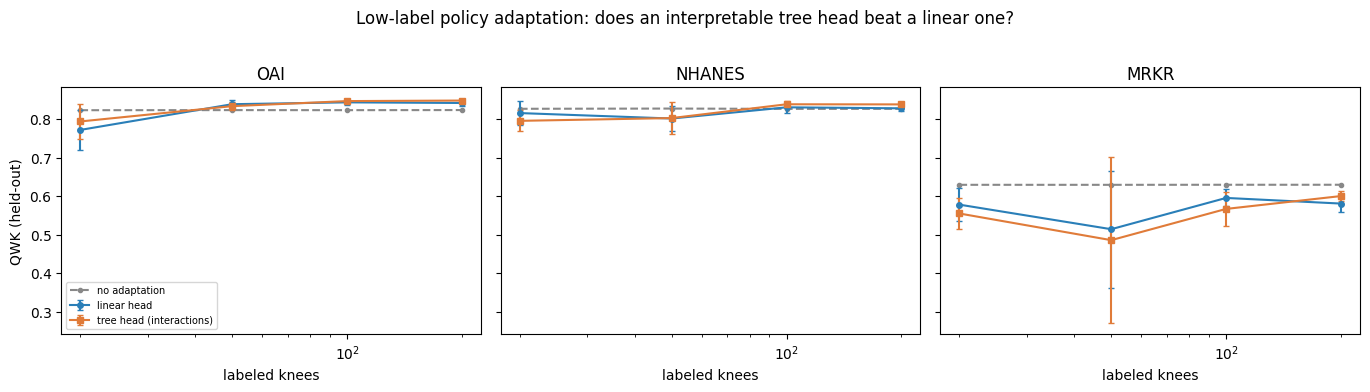

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

LEARNED GRADING POLICY (the thing that differs between hospitals)

OAI  linear policy weights: {'osteophyte': 0.366, 'jsn': 0.368, 'sclerosis': 0.266}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


NHANES  linear policy weights: {'osteophyte': 0.486, 'jsn': 0.268, 'sclerosis': 0.246}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


MRKR  linear policy weights: {'osteophyte': 0.283, 'jsn': 0.404, 'sclerosis': 0.313}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
fig, axes = plt.subplots(1, len(PRESENT), figsize=(4.6*len(PRESENT), 3.8), sharey=True, squeeze=False)
for ax, c in zip(axes[0], PRESENT):
    d = res[res.cohort == c]
    if d.empty: continue
    ax.plot(d.calib_n, d.noadapt_qwk, "--", color="#888", marker="o", ms=3, label="no adaptation")
    ax.errorbar(d.calib_n, d.linear_qwk, yerr=d.linear_sd, color="#2a7fb8", marker="o", ms=4, capsize=2, label="linear head")
    ax.errorbar(d.calib_n, d.tree_qwk, yerr=d.tree_sd, color="#e07b39", marker="s", ms=4, capsize=2, label="tree head (interactions)")
    ax.set_xscale("log"); ax.set_title(c); ax.set_xlabel("labeled knees")
axes[0][0].set_ylabel("QWK (held-out)"); axes[0][0].legend(fontsize=7)
plt.suptitle("Low-label policy adaptation: does an interpretable tree head beat a linear one?", y=1.02)
plt.tight_layout(); plt.show()

# Show the actual learned policy -- this is the interpretability payoff
print("=" * 70); print("LEARNED GRADING POLICY (the thing that differs between hospitals)"); print("=" * 70)
for c in PRESENT:
    sub = df[df.dataset == c].reset_index(drop=True)
    X, y = sub[FEAT_COLS].to_numpy(), sub["kl_label"].to_numpy()
    cm = group_calib_split(sub, 200, SEED)
    lin = fit_linear(X[cm], y[cm])
    if lin is not None:
        w = np.abs(lin.coef_).mean(0); w = w / max(w.sum(), 1e-9)
        print("\n%s  linear policy weights: %s" % (c, {f: round(float(v), 3) for f, v in zip(FEATS, w)}))
    tre = fit_tree(X[cm], y[cm])
    if tre is not None and not HAS_FIGS:
        print(export_text(tre, feature_names=FEATS, max_depth=2)[:400])

## Part 5 — Test-time intervention: the CBM superpower

A concept bottleneck lets you **overwrite** the predicted findings with ground truth at test time and re-predict
the grade — no retraining. Sweep the fraction replaced from 0% to 100%:

- If accuracy **climbs steeply** → the errors live in `P(Findings|Image)` (the model mis-*sees*). Fix the extractor.
- If accuracy **stays flat** → the errors live in `P(Grade|Findings)` (the model mis-*combines*). Fix the policy.

This attributes the error to a specific stage, per cohort — something an end-to-end model can't tell you. Ground
truth findings exist for OAI; because Mendeley is the same knees (Part 1), OAI's ground truth transfers to the
Mendeley-path rows, letting us ask: *if we hand the model the true findings, does the pipeline damage vanish?*

> **Protocol note.** The policy head here is fit on **ground-truth** findings (an *independent* CBM). This matters:
> a head fit on *predicted* findings silently learns to compensate for the extractor's bias, and then intervening
> with ground truth breaks that compensation — the documented failure mode where intervention doesn't reduce task
> error. Fitting on ground truth makes the head a faithful model of the true policy, so the curve measures what we
> intend. Consequently the 0% point is *not* the same as Part 4's deployed accuracy; the *shape* is the result.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

intervening on: ['osteophyte_true', 'jsn_true', 'sclerosis_true'] 



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

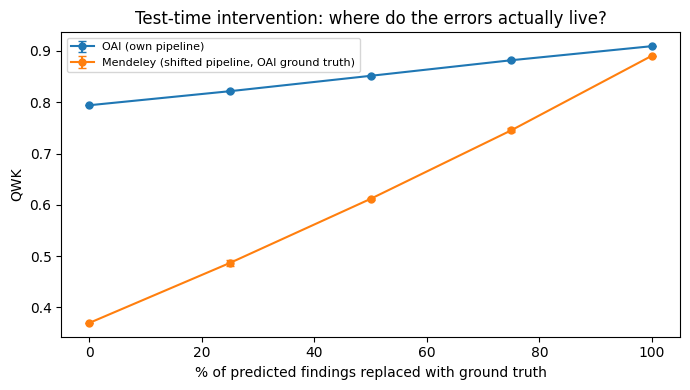

OAI (own pipeline)                             QWK 0.794 -> 0.909  (lift +0.115)
Mendeley (shifted pipeline, OAI ground truth)  QWK 0.370 -> 0.890  (lift +0.520)

Steep lift => errors are in Image->Findings (fix the extractor).
Flat curve => errors are in Grade|Findings (fix the policy head).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def intervention_curve(sub, gt_cols, fractions=(0.0, 0.25, 0.5, 0.75, 1.0), reps=3):
    valid = np.ones(len(sub), bool)
    for t in gt_cols:
        valid &= sub[t].notna().to_numpy() & (sub[t].to_numpy() != MISSING_SENTINEL)
    s = sub[valid].reset_index(drop=True)
    if len(s) < 100: return None
    X, y = s[FEAT_COLS].to_numpy().astype(float), s["kl_label"].to_numpy()
    G = s[gt_cols].to_numpy().astype(float)
    cm = group_calib_split(s, 200, SEED); em = ~cm

    head = fit_tree(G[cm], y[cm])
    fb = int(pd.Series(y).mode().iloc[0])
    out = []
    for fr in fractions:
        a, q = [], []
        for rep in range(reps):
            rng = np.random.default_rng(rep)
            Xi = X.copy()
            for j in range(X.shape[1]):
                mask = rng.random(len(X)) < fr
                Xi[mask, j] = G[mask, j]
            p = pred_or(head, Xi[em], fb)
            a.append(acc(y[em], p)); q.append(qwk(y[em], p))
        out.append(dict(frac=fr, acc=np.mean(a), qwk=np.mean(q), qwk_sd=np.std(q)))
    return pd.DataFrame(out)

gt_cols = [f + "_true" for f in FEATS if (f + "_true") in df.columns]
if not gt_cols:
    print("No ground-truth finding columns -> Part 5 skipped.")
else:
    print("intervening on:", gt_cols, "\n")
    curves = {}
    d_oai = df[df.dataset == "OAI"]
    c1 = intervention_curve(d_oai, gt_cols)
    if c1 is not None: curves["OAI (own pipeline)"] = c1

    # Mendeley-path rows, using OAI's ground-truth findings for the same knee
    dk = add_knee_key(df)
    gt_map = add_knee_key(d_oai).dropna(subset=["knee_key"]).set_index("knee_key")[gt_cols]
    men = dk[(dk.dataset == "Mendeley") & dk.knee_key.isin(gt_map.index)].copy()
    if len(men) > 100:
        for t in gt_cols: men[t] = gt_map.loc[men.knee_key, t].values
        c2 = intervention_curve(men, gt_cols)
        if c2 is not None: curves["Mendeley (shifted pipeline, OAI ground truth)"] = c2

    if curves:
        fig, ax = plt.subplots(figsize=(7, 4))
        for name, c in curves.items():
            ax.errorbar(c.frac*100, c.qwk, yerr=c.qwk_sd, marker="o", ms=5, capsize=3, label=name)
        ax.set_xlabel("% of predicted findings replaced with ground truth")
        ax.set_ylabel("QWK"); ax.legend(fontsize=8)
        ax.set_title("Test-time intervention: where do the errors actually live?")
        plt.tight_layout(); plt.show()
        for name, c in curves.items():
            lift = c.qwk.iloc[-1] - c.qwk.iloc[0]
            print("%-46s QWK %.3f -> %.3f  (lift %+.3f)" % (name, c.qwk.iloc[0], c.qwk.iloc[-1], lift))
        print("\nSteep lift => errors are in Image->Findings (fix the extractor).")
        print("Flat curve => errors are in Grade|Findings (fix the policy head).")